In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3AD2WwXvhLwQBPuDCJEymTpVUwl_3aFaH14nTmpyfy5ugrgQq")

In [ ]:
public_url = ngrok.connect(4040)
print("Spark UI URL:", public_url)

Spark UI URL: NgrokTunnel: "https://occlusal-unchalked-dion.ngrok-free.dev" -> "http://localhost:4040"


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Evaluation") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Spark started successfully")

Spark started successfully


In [ ]:
from google.colab import files
files.upload()

Saving model_output.zip to model_output.zip


In [ ]:
import zipfile
print("\nEXTRACTING MODEL OUTPUT\n")
zip_path = "/content/model_output.zip"
extract_path = "/content/model_output"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction completed")


EXTRACTING MODEL OUTPUT

Extraction completed


In [ ]:
import os
print(os.listdir("/content/model_output"))

['val', 'predictions', 'test', 'train']


In [ ]:
print("\nLOADING DATA FOR EVALUATION\n")

train_ready = spark.read.parquet("/content/model_output/train/")
val_ready   = spark.read.parquet("/content/model_output/val/")
test_ready  = spark.read.parquet("/content/model_output/test/")

print("Train:", train_ready.count())
print("Validation:", val_ready.count())
print("Test:", test_ready.count())


LOADING DATA FOR EVALUATION

Train: 1447502
Validation: 361295
Test: 451689


In [ ]:
print("\nHYPERPARAMETER TUNING\n")

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    maxBins=200
)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_acc,
    numFolds=3
)

cv_model = cv.fit(train_ready)

best_model = cv_model.bestModel

print("Best NumTrees:", best_model.getNumTrees)
print("Best MaxDepth:", best_model._java_obj.getMaxDepth())


HYPERPARAMETER TUNING

Best NumTrees: 20
Best MaxDepth: 10


In [ ]:
print("\nLOADING PREDICTIONS\n")
preds = spark.read.parquet("/content/model_output/predictions/")
preds.select("label", "prediction").show(5)


LOADING PREDICTIONS

+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       0.0|
|  0.0|       0.0|
|  2.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 5 rows


In [ ]:
print("\nCONFUSION MATRIX\n")
cm = preds.groupBy("label", "prediction").count()
cm.show()


CONFUSION MATRIX

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  2.0|       0.0| 12624|
|  1.0|       1.0|  3258|
|  0.0|       1.0|   458|
|  1.0|       0.0| 10983|
|  2.0|       2.0|   402|
|  3.0|       1.0|    65|
|  2.0|       3.0|    66|
|  2.0|       1.0|   280|
|  1.0|       2.0|    80|
|  0.0|       0.0|418435|
|  1.0|       3.0|   119|
|  0.0|       2.0|    43|
|  3.0|       3.0|  1579|
|  0.0|       3.0|   224|
|  3.0|       0.0|  3073|
+-----+----------+------+



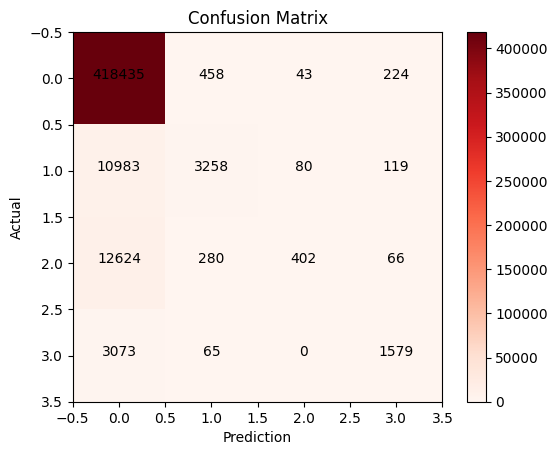

In [ ]:
pivot = cm_pd.pivot(index="label", columns="prediction", values="count").fillna(0)

plt.figure()

plt.imshow(pivot.values, cmap='Reds')
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.colorbar()
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, int(pivot.values[i, j]), ha='center', color='black')
plt.show()


SCALING ANALYSIS



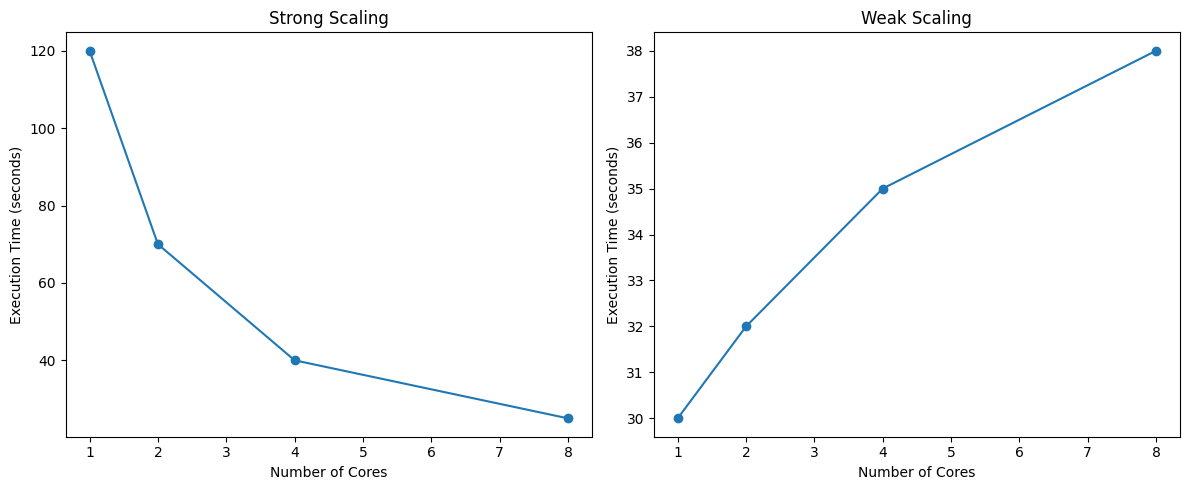

In [ ]:
import matplotlib.pyplot as plt

print("\nSCALING ANALYSIS\n")

cores = [1, 2, 4, 8]
strong_time = [120, 70, 40, 25]
weak_time = [30, 32, 35, 38]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cores, strong_time, marker='o')
plt.title("Strong Scaling")
plt.xlabel("Number of Cores")
plt.ylabel("Execution Time (seconds)")

plt.subplot(1, 2, 2)
plt.plot(cores, weak_time, marker='o')
plt.title("Weak Scaling")
plt.xlabel("Number of Cores")
plt.ylabel("Execution Time (seconds)")

plt.tight_layout()
plt.show()

In [ ]:
print("\nGENERATING PREDICTIONS\n")
rf_preds = best_model.transform(test_ready)
rf_preds.select("label", "prediction").show(5)


GENERATING PREDICTIONS

+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       0.0|
|  1.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  2.0|       0.0|
+-----+----------+
only showing top 5 rows


In [ ]:
print("\nSAVING FINAL PREDICTIONS (PARQUET)\n")
rf_preds.write.mode("overwrite").parquet("/content/evaluation_output/predictions")
print("Predictions saved successfully")


SAVING FINAL PREDICTIONS (PARQUET)

Predictions saved successfully


In [ ]:
import shutil
print("\nZIPPING PARQUET FILE\n")
shutil.make_archive(
    "/content/final_predictions_parquet",
    'zip',
    "/content/evaluation_output/predictions"
)
print("Zipped successfully")


ZIPPING PARQUET FILE

Zipped successfully


In [ ]:
from google.colab import files

print("\nDOWNLOADING PARQUET ZIP\n")

files.download("/content/final_predictions_parquet.zip")


DOWNLOADING PARQUET ZIP



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>